In [5]:
import os
import sys
import warnings

# Path = '/remote/tychodata/ftairli/work/Projects/LSTM_Reconstruction/Models'
# if Path not in sys.path: sys.path.append(Path)
warnings.filterwarnings('ignore')

from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from copy import deepcopy

hostname = os.uname()
if 'tedtop' in hostname: sys.path.append('/home/fedor-tairli/work/CDEs/Dataset/')


from Dataset2 import ProcessingDatasetContainer

if 'tedtop' in hostname: plt.style.use('/home/fedor-tairli/work/MPLStylefiles/Vscode_DarkModern_Invisible.mplstyle')



In [6]:
Model_Name = 'Model_Autoencoder_TimeFit'

Dataset_Name = 'Autoencoder_TimeFit_Dataset'

In [7]:
hostname

posix.uname_result(sysname='Linux', nodename='tycho.physics.adelaide.edu.au', release='3.10.0-1160.88.1.el7.x86_64', version='#1 SMP Tue Mar 7 15:41:52 UTC 2023', machine='x86_64')

#### Loading Data and Models, Processing Predictions

In [8]:
if 'tycho' in hostname or 'tycho' in hostname.nodename:
    Models_Path  = '/remote/tychodata/ftairli/work/CDEs/AutoencoderGeometry/Models'
    Dataset_Path = '/remote/tychodata/ftairli/work/CDEs/AutoencoderGeometry/Data/'
if 'tedtop' in hostname:
    Models_Path  = '/home/fedor-tairli/work/CDEs/AutoencoderGeometry/Models'
    Dataset_Path = '/home/fedor-tairli/work/CDEs/AutoencoderGeometry/Data/'

# append models path to path
sys.path.append(Models_Path)


In [9]:
# Load Model and Tracker Here
Model = torch.load(f'{Models_Path}/{Model_Name}.pt')
Tracker = torch.load(f'{Models_Path}/{Model_Name}_Tracker.pt')
print(Model.Description)

Model will try to figure out a state representation of the shower time profile
    Reconstruction of geometry is done from this state
    Training to be done in two steps
    1. train the autoencoder to reconstruct the time profile
        -  to do this, model will observe the data and try to produce 10 new values from the profile
    2. train the decoder that will use the latent state to reconstruct the geometry
        
    


In [10]:
# Import Dataset Here

# datapath = '/remote/tychodata/ftairli/work/Projects/ProfileReconstruction/Data/'
# Dataset = ProcessingDatasetContainer(datapath)
Dataset = torch.load(f'{Dataset_Path}/{Dataset_Name}.pt')
print(Dataset.Name)
print(Dataset.Truth_Keys)
print(f'Dataset Length : {len(Dataset)}')
Dataset.AssignIndices()
# Dataset.State = 'Train'
# print(len(Dataset))

Unassigned_EPOSLHC_R_Run010_EPOSLHC_R_Run030_EPOSLHC_R_Run080_EPOSLHC_R_Run030
['Chi_0', 'Rp', 'T0']
Dataset Length : 816108


In [11]:
# Some Information
print(f'Final Epoch             : {len(Tracker.EpochLoss["Total"])  } ')
if len(Tracker.EpochLoss)>10 :
    print(f'Epoch 10 Loss           : {Tracker.EpochLoss    ["Total"][9]} ')
    print(f'Epoch 10 Validation Loss: {Tracker.EpochValLoss ["Total"][9]} ')
print(f'Final Loss              : {Tracker.EpochLoss    ["Total"][-1]}')
print(f'Final Validation Loss   : {Tracker.EpochValLoss ["Total"][-1]}')


Final Epoch             : 60 
Final Loss              : 110259.4831545977
Final Validation Loss   : 110452.1640625


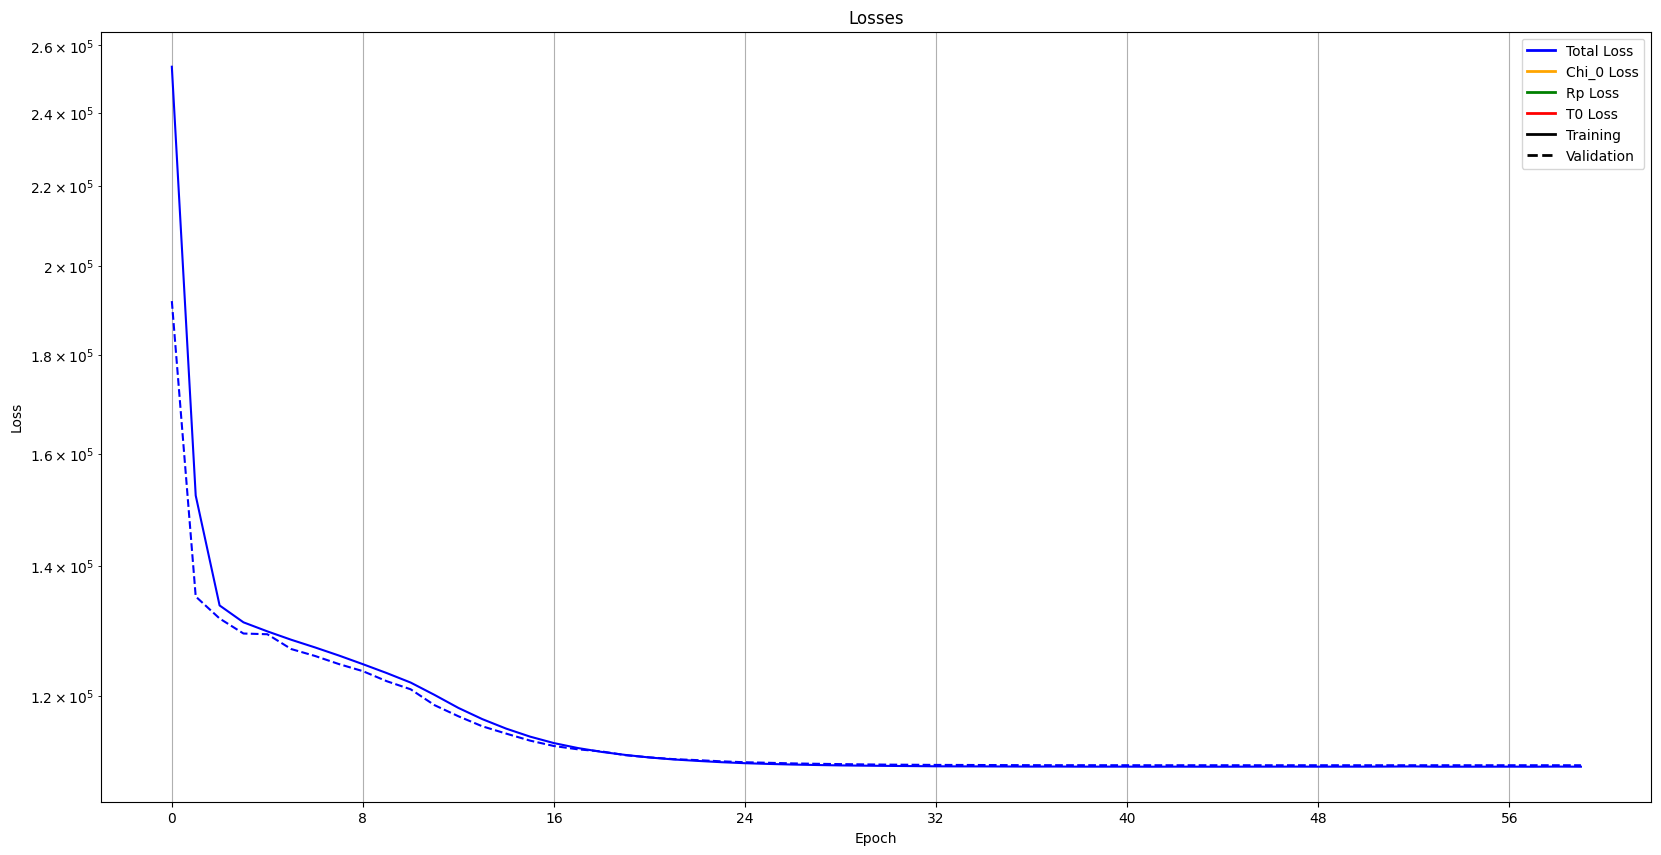

In [12]:
# Loss Plot
EpochLosses    = Tracker.EpochLoss
EpochValLosses = Tracker.EpochValLoss
Keys = list(EpochLosses.keys())
Nepochs = len(EpochLosses[Keys[0]])

ax = plt.figure(figsize=(20, 10)).gca()

# Define colors
colors = ['blue', 'orange', 'green', 'red','cyan','purple','magenta','yellow']


custom_lines = []
custom_keys  = []
for i in range(len(Keys)):
    plt.plot(EpochLosses[Keys[i]]   , color=colors[i], label=Keys[i] + ' - Training')
    plt.plot(EpochValLosses[Keys[i]], color=colors[i], label=Keys[i] + ' - Validation', linestyle='dashed')
    custom_lines.append(Line2D([0], [0], color=colors[i], lw=2))
    custom_keys.append(Keys[i]+' Loss')

custom_lines+= [Line2D([0], [0], color='black', lw=2),
                Line2D([0], [0], color='black', lw=2, linestyle='dashed')]
custom_keys += ['Training', 'Validation']


ax.legend(custom_lines, custom_keys)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # integer ticks
ax.set_title('Losses')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.grid()

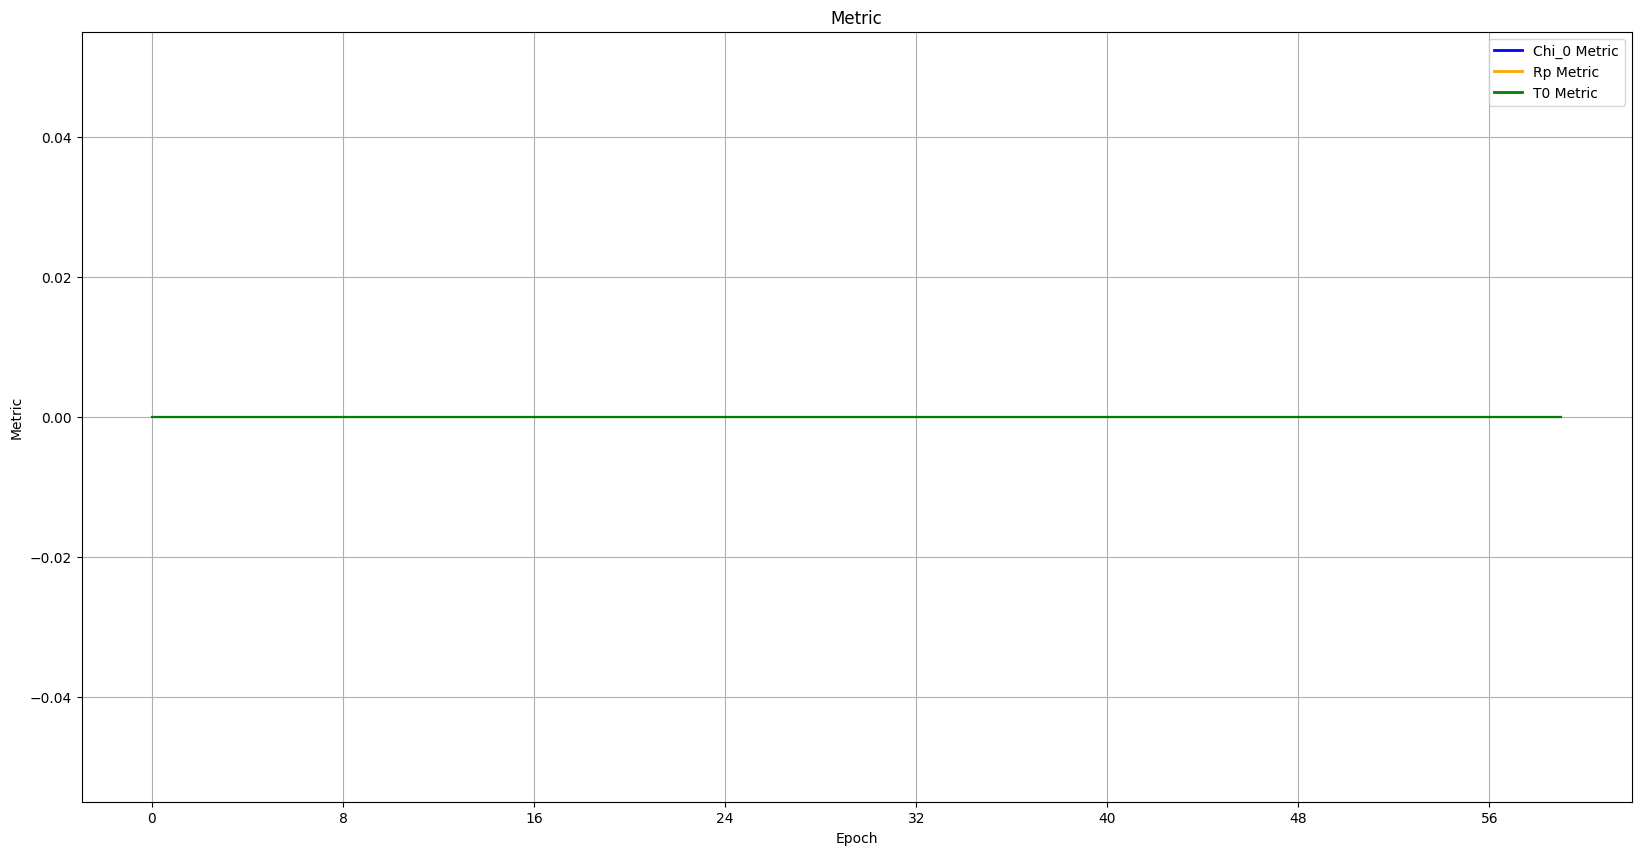

In [15]:
# Metric Plot

# Loss Plot
EpochMetrics    = Tracker.EpochMetric
Keys  = Dataset.Truth_Keys
Units = Dataset.Truth_Units
Nepochs = len(EpochLosses[Keys[0]])

ax = plt.figure(figsize=(20, 10)).gca()

# Define colors
colors = ['blue', 'orange', 'green', 'red','cyan','purple','magenta','yellow']


custom_lines = []
custom_keys  = []
for i in range(len(Keys)):
    plt.plot(np.array(EpochMetrics[Keys[i]])     , color=colors[i], label=Keys[i] + ' - Metric')
    custom_lines.append(Line2D([0], [0], color=colors[i], lw=2))
    custom_keys.append(Keys[i]+' Metric')



ax.legend(custom_lines, custom_keys)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # integer ticks
ax.set_title('Metric')
ax.set_xlabel('Epoch')
ax.set_ylabel('Metric')
# ax.set_yscale('log')
ax.grid()

In [16]:
# Define some metrics
def MeanSquaredError(Truths,Predictions):
    return ((Truths-Predictions)**2).mean()
def MeanAbsoluteError(Truths,Predictions):
    return (np.abs(Truths-Predictions)).mean() if type(Truths) != torch.Tensor else (torch.abs(Truths-Predictions)).mean()
def Percentile68(Truths,Predictions):
    return np.percentile(np.abs(Truths-Predictions),68) if type(Truths) != torch.Tensor else torch.quantile(torch.abs(Truths-Predictions),0.68)

In [17]:
# Compute the Test Set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
Model.to(device)
torch.cuda.empty_cache()

Dataset.State      = 'Test'
Dataset.BatchSize  = len(Dataset)//256
# Dataset.BatchSize  = 64
Dataset.RandomIter = False

Truth   = []
Rec     = []
Pred    = []
Mains   = []
Auxs    = []


Model.eval()
EvI = 0
with torch.no_grad():
    for EventIndex,BatchMains, BatchAux,BatchTruth,BatchRec in Dataset:
        Truth .append(BatchTruth)
        Rec   .append(BatchRec)
        Mains .append(deepcopy(BatchMains))
        Auxs  .append(BatchAux)

        if Model_Name == 'Model_Autoencoder_TimeFit':
            Model_Out = Model(BatchMains, BatchAux)

            Pred   .append(Model_Out['time_profile'].cpu())
            
        EvI+=1
        # if EvI == 10: break

print()
Truth   = torch.cat(Truth  , dim=0)
Rec     = torch.cat(Rec    , dim=0)
Pred    = torch.cat(Pred   , dim=0)
Auxs    = torch.cat(Auxs   , dim=0)




Truth   = Truth.numpy()
Rec     = Rec  .numpy()
Pred    = Pred .numpy()
Auxs    = Auxs .numpy()

print(Truth.shape)
print(Pred.shape)



chi_is = []
charge = []
time   = []

station_chii = []
station_time = []
station_signal = []


for Batch in Mains:
    for Main in Batch:
        chi_is.append(Main['chi_is'].numpy())
        charge.append(Main['charge'].numpy())
        time  .append(Main['time']  .numpy())

        station_chii.append(Main['station_chii'].item())
        station_time.append(Main['station_time'].item())
        station_signal.append(Main['station_signal'].item())

station_time = np.array(station_time)
station_signal = np.array(station_signal)
station_chii  = np.array(station_chii)

print(f'Station Measurements lengths: {len(station_time)}, {len(station_signal)}, {len(station_chii)}')
print(f'Total Mains split into showers = {len(chi_is)}')
        


(81611, 3)
(81611, 10, 2)
Station Measurements lengths: 81611, 81611, 81611
Total Mains split into showers = 81611


In [18]:
def time_fit(chii,chi_0,Rp,T0):
    
    in_tan  = (chi_0 - chii)/2
    scale = Rp/(3e8)
    time_profile = T0/1e9 + scale*torch.tan(in_tan)
    return time_profile*1e7 # return in 100ns units - telescope bins
    

def time_fit_np(chii,chi_0,Rp,T0):
    
    in_tan  = (chi_0 - chii)/2
    scale = Rp/(3e8)
    time_profile = T0/1e9 + scale*np.tan(in_tan)
    return time_profile*1e7 # return in 100ns units - telescope bins




In [24]:
# Generate the Truth Data

Chi_0s = Truth[:,0]
Rp     = Truth[:,1]
T0     = Truth[:,2]

test_chis = np.linspace(0, 1, num=10).reshape(1, -1).repeat(len(Pred), axis=0)  # (B, 10) # between 0 and 1
test_chis = test_chis * np.ones_like(Chi_0s[:, np.newaxis])*np.pi  # (B, 10) # between 0 and chi_0

Time_Profile_Truth  = time_fit_np(test_chis, Chi_0s[:, np.newaxis], Rp[:, np.newaxis], T0[:, np.newaxis])  # (B, 10)
Time_Profile_Pred   = Pred[:,:,1]  # (B, 10)
Chii_Profile_Truth  = test_chis  # (B, 10)
Chii_Profile_Pred   = Pred[:,:,0]

print(f'Time Profile Truth Shape: {Time_Profile_Truth.shape}')
print(f'Time Profile Pred Shape: {Time_Profile_Pred.shape}')



Time Profile Truth Shape: (81611, 10)
Time Profile Pred Shape: (81611, 10)


[0.00314486 0.35482204 0.85996854 1.0733646  1.358771   1.6391971
 1.8729416  2.090681   2.1574984  2.251649  ]
[0.         0.34906585 0.6981317  1.04719755 1.3962634  1.74532925
 2.0943951  2.44346095 2.7925268  3.14159265]
[ 487.36517   372.18866   261.23895   159.58688    60.102623  -38.080036
 -130.60442  -207.88454  -273.74976  -322.82675 ]
[ 397.85334029  303.97217416  222.46435514  146.7511769    71.87535086
   -6.90164533  -95.37091222 -202.31040764 -343.69912837 -554.53524235]


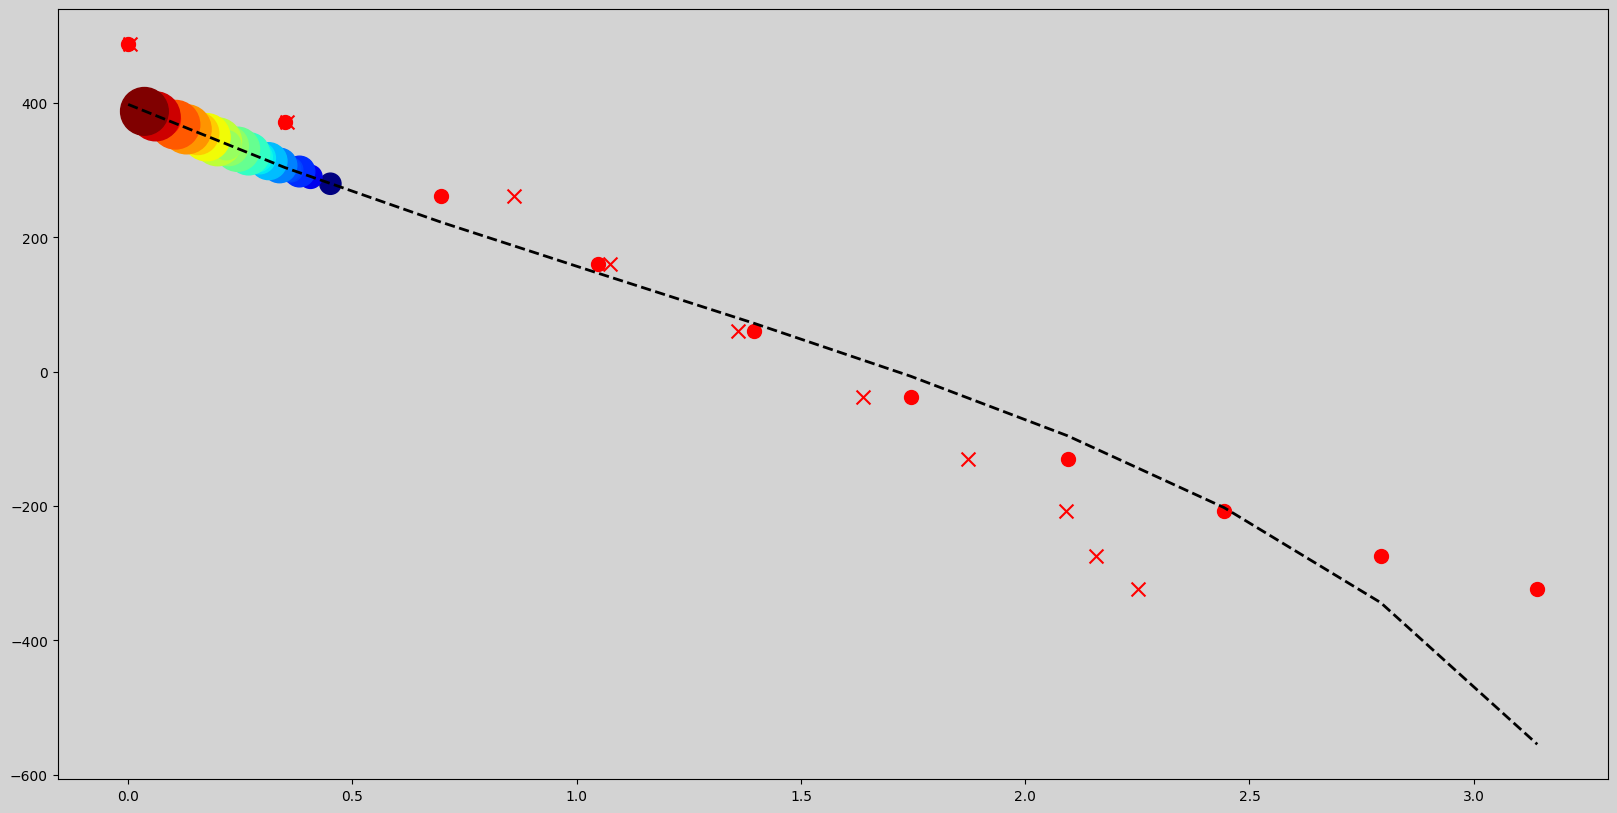

In [57]:
Event_Found = False
while not Event_Found:
    N = np.random.randint(0, len(Pred))
    if len(chi_is[N]) > 10: Event_Found = True


fig, ax = plt.subplots(1,1,figsize=(20, 10))
ax.set_facecolor('lightgray')
fig.set_facecolor('lightgray')

t_chii = chi_is[N]
t_charge = charge[N]
t_time   = time[N]

t_chii_preds = Chii_Profile_Pred[N]
t_chii_truth = Chii_Profile_Truth[N]
t_time_preds = Time_Profile_Pred[N]
t_time_truth = Time_Profile_Truth[N]

print(t_chii_preds)
print(t_chii_truth)
print(t_time_preds)
print(t_time_truth)


ax.scatter(t_chii, t_time, c = t_time, cmap='jet',s=10*np.sqrt(t_charge), label='Measured Values')

ax.plot(Chii_Profile_Truth[N], Time_Profile_Truth[N], color='black', label='Truth Profile', linewidth=2, linestyle='dashed') 
ax.scatter(Chii_Profile_Truth[N], Time_Profile_Pred[N], color='red', label='Predicted Profile', s=100)
ax.scatter(Chii_Profile_Pred[N], Time_Profile_Pred[N], color='red',marker='x', label='Predicted Profile', s=100)

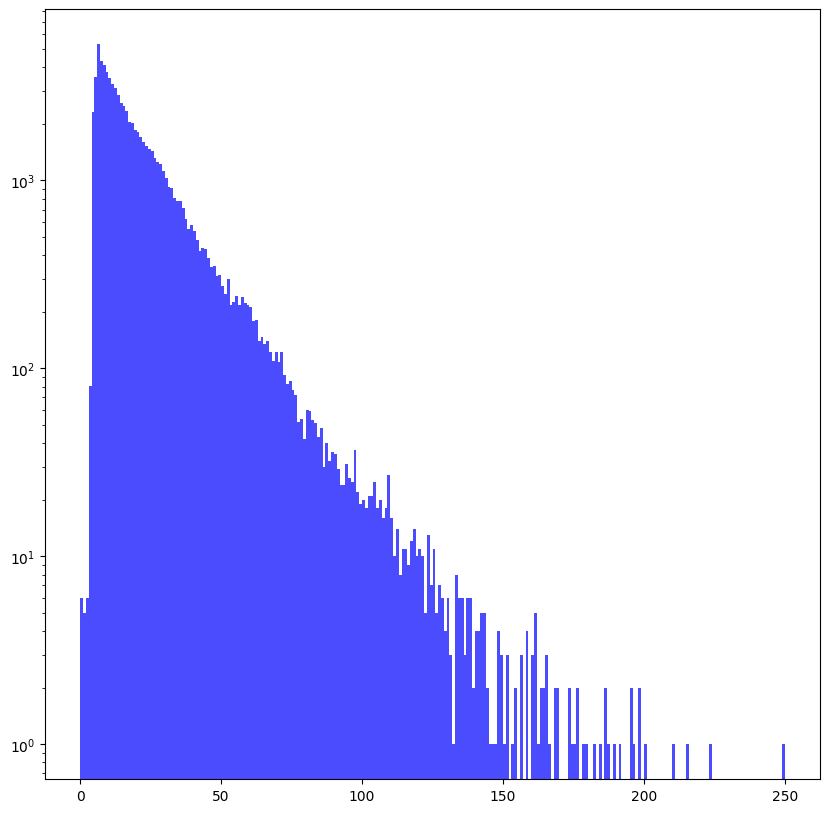

In [60]:
Time_Diffs = Time_Profile_Truth - Time_Profile_Pred
Chii_Diffs = Chii_Profile_Truth - Chii_Profile_Pred


Event_Lenghts = np.array([ len(chi) for chi in chi_is])


plt.figure(figsize = (10,10))
plt.hist(Event_Lenghts, bins=np.arange(0, max(Event_Lenghts)+1, 1), color='blue', alpha=0.7)
plt.yscale('log')
plt.show()

[  1.           1.33723387   1.78819443   2.39123416   3.19763932
   4.27599161   5.71800082   7.64630438  10.22489722  13.6730789
  18.28410425  24.45012353  32.69553337  43.72157471  58.46597066
  78.18267636 104.54852307 139.80582638 186.95308661 250.        ]


<ErrorbarContainer object of 3 artists>

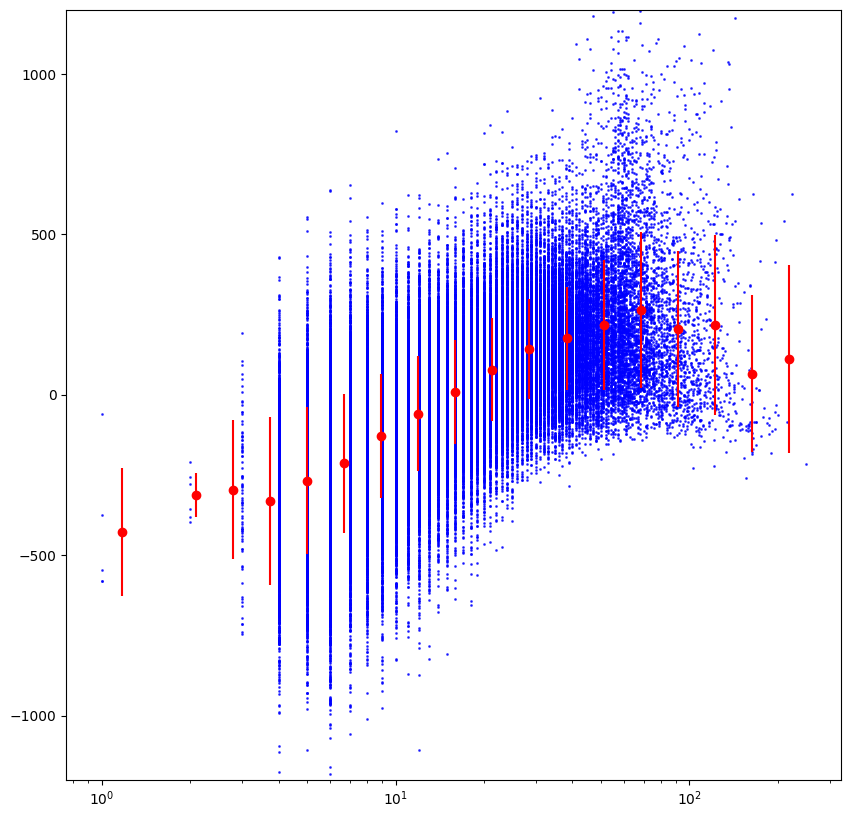

In [72]:
Mean_Time_Diff = np.mean(Time_Diffs, axis=1)

plt.figure(figsize=(10, 10))
plt.scatter(Event_Lenghts, Mean_Time_Diff, color='blue', alpha=0.7,s=1)
plt.xscale('log')
# plt.yscale('log')

plt.ylim(-1200,1200)


Bins = np.logspace(0, np.log10(max(Event_Lenghts)), num=20)
print(Bins)

Binned_Mean_Time_Diff = []
Binned_Mean_Time_Diffs_std = []

for i in range(len(Bins)-1):
    bin_mask = (Event_Lenghts >= Bins[i]) & (Event_Lenghts < Bins[i+1])
    if np.sum(bin_mask) > 0:
        binned_mean_diff = np.mean(Mean_Time_Diff[bin_mask])
        binned_mean_diff_std = np.std(Mean_Time_Diff[bin_mask])
    else:
        binned_mean_diff = np.nan
        binned_mean_diff_std = np.nan
    Binned_Mean_Time_Diff.append(binned_mean_diff)
    Binned_Mean_Time_Diffs_std.append(binned_mean_diff_std)
Binned_Mean_Time_Diff = np.array(Binned_Mean_Time_Diff)
Binned_Mean_Time_Diffs_std = np.array(Binned_Mean_Time_Diffs_std)
Bin_Centers = (Bins[:-1] + Bins[1:]) / 2
plt.errorbar(Bin_Centers, Binned_Mean_Time_Diff, yerr=Binned_Mean_Time_Diffs_std, fmt='o', color='red', label='Binned Mean Time Diff')


